# FNN (MLPRegressor) — Wind Speed Forecasting
## Variable Set 1

In [3]:
# =============================================================================
# INSTALLING PACKAGES
# =============================================================================
# !pip install statsmodels optuna tabulate gdown scikit-learn

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.4 MB/s eta 0:00:00


In [5]:
# =============================================================================
# IMPORTS
# =============================================================================

# Standard libraries
import os
import sys
import random
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap

# Scikit-learn: preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn import model_selection, metrics, preprocessing

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)

# Scikit-learn: models & metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Statistical analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pointbiserialr, chi2_contingency, spearmanr, entropy, uniform
from statsmodels.graphics.gofplots import qqplot

# Tabulate
from tabulate import tabulate

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress Optuna trial logs

# Google Drive download
import gdown

# Global random seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Set visualization style
#sns.set()  # Set Seaborn default style
#plt.style.use('ggplot')  # Set ggplot style for matplotlib

In [6]:
# =============================================================================
# LOADING THE DATA SET
# =============================================================================
# Dataset source:
# https://drive.google.com/file/d/1Z_KsoIumw-fvivVombIoWuRo0LOe2nCb/view?usp=sharing
# https://drive.google.com/file/d/1aD1PXfwEEZ_F2lQgxuPfj-TVbxQ6NajK/view?usp=sharing

file_id      = "1qhCB1Dod6jeEsuKy5sNk4MNHSjtENSrx"
download_url = f"https://drive.google.com/uc?id={file_id}"

# Read the data
df = pd.read_csv(download_url)

# Backup original DataFrame
df_backup = df.copy()

In [7]:
# =============================================================================
# DATA PREPROCESSING
# =============================================================================

# Create datetime directly from differently named columns
df['Date'] = pd.to_datetime({
    'year': df['YEAR'],
    'month': df['MO'],
    'day': df['DY']
})

# Set Date as the index
df = df.set_index('Date')

# Drop unnecessary columns
df = df.drop(columns=["YEAR", "MO", "DY"])

# Display the DataFrame (optional in scripts)
print(df.head())
print("\nColumns:", df.columns.tolist())

            WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79       1.65  

In [8]:
# =============================================================================
# TRAIN / TEST SPLIT  (80% train — 20% test, temporal order preserved)
# =============================================================================
## Data Sets

# Define features and target
X = df.drop(columns=['WS10M'])   # Features (lagged variables)
y = df['WS10M']                  # Target variable (wind speed)

numerical_cols = df.columns

# Define the split index — 80% for training, 20% for testing
split_index = int(len(X) * 0.8)

# Training set
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing set
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("X_train:\n", X_train.head())
print("y_train:\n", y_train.head())
print("X_test:\n",  X_test.head())
print("y_test:\n",  y_test.head())

print("\nShapes:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train:
             WS10M_lag1   PREC     RH  MIN_TEMP  MAX_TEMP    WD_sin  \
Date                                                                 
2013-01-03        4.25  13.42  86.26     23.42     28.38  0.439939   
2013-01-04        4.75   8.79  86.31     22.93     27.58  0.424199   
2013-01-05        5.74   2.60  86.88     22.17     26.16  0.563526   
2013-01-06        5.79   1.65  88.09     23.47     27.75  0.460200   
2013-01-07        4.52  27.41  93.04     24.04     26.70  0.368125   

            SURF_PRESSSURE    WD_cos  AVG_TEMP  WS10M_lag2  PREC_lag1  \
Date                                                                    
2013-01-03           99.68  0.898028      26.4        3.99       1.09   
2013-01-04           99.65  0.905569      25.1        4.25      13.42   
2013-01-05           99.50  0.826098      26.9        4.75       8.79   
2013-01-06           99.47  0.887815      27.3        5.74       2.60   
2013-01-07           99.46  0.929776      25.9        5.79   

In [9]:
# =============================================================================
# SCALING
# FIX: Scaler is fit once on X_train only and reused across all sections.
#      Fitting the scaler separately in each section is redundant and risks
#      inconsistency if X_train ever changes between sections.
# =============================================================================

# ===== CRITICAL ADDITION: STANDARD SCALING =====
# Initialize scaler — fit on training data only, never on test data
scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit and transform train
X_test_scaled  = scaler.transform(X_test)        # Transform test using train statistics


# =============================================================================
# EVALUATION FUNCTION  (defined once, reused across all sections)
# =============================================================================

# Evaluation Function
def evaluate_metrics(y_true, y_pred, label=""):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"{label} MSE:  {mse:.4f}")
    print(f"{label} RMSE: {rmse:.4f}")
    print(f"{label} MAE:  {mae:.4f}")
    print(f"{label} MAPE: {mape:.2f}%")
    print(f"{label} R²:   {r2:.4f}")
    return mse, rmse, mae, mape, r2

## Section 1 — Original FNN Model (No Hyperparameter Optimisation)


--- FNN Original Model Evaluation ---
Train (FNN) MSE:  0.2371
Train (FNN) RMSE: 0.4869
Train (FNN) MAE:  0.3804
Train (FNN) MAPE: 10.63%
Train (FNN) R²:   0.9059
Test (FNN) MSE:  0.6349
Test (FNN) RMSE: 0.7968
Test (FNN) MAE:  0.6061
Test (FNN) MAPE: 16.37%
Test (FNN) R²:   0.7367
            Actual  Predicted
Date                         
2021-10-20    2.82   3.500737
2021-10-21    2.79   3.580940
2021-10-22    2.72   2.397601
2021-10-23    4.30   2.662486
2021-10-24    3.74   2.992536
2021-10-25    2.69   2.995662
2021-10-26    2.37   2.514045
2021-10-27    2.30   2.587401
2021-10-28    3.50   3.705382
2021-10-29    4.15   3.962633
2021-10-30    1.97   3.891881
2021-10-31    5.60   3.772945
2021-11-01    6.11   4.329891
2021-11-02    2.57   4.172335
2021-11-03    3.27   2.813989
2021-11-04    3.36   3.505874
2021-11-05    3.55   3.523982
2021-11-06    4.03   3.531773
2021-11-07    5.18   3.310350
2021-11-08    5.81   4.381796


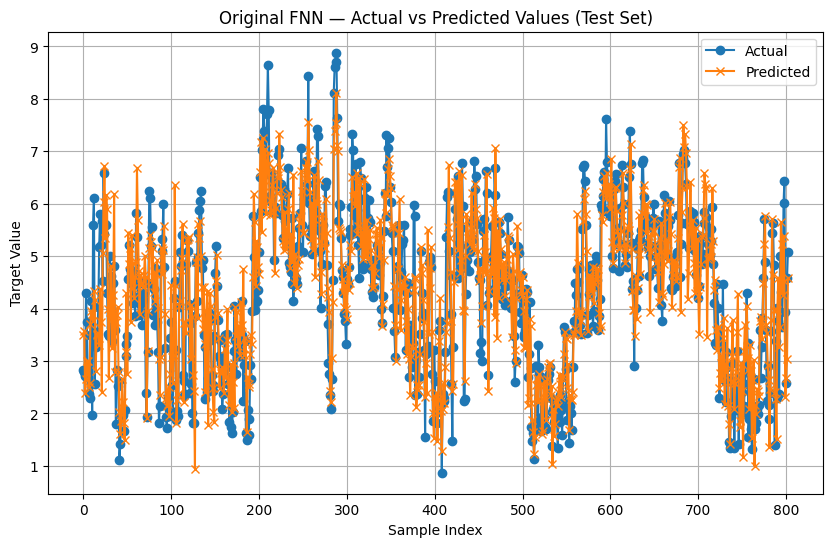

In [10]:
# =============================================================================
# SECTION 1 — ORIGINAL FNN MODEL  (No Hyperparameter Optimisation)
# =============================================================================
## FNN Original

# Initialize FNN model
fnn_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),  # You can modify this architecture
    activation='relu',             # relu is common; can try 'tanh' or 'logistic'
    solver='adam',                 # 'adam' is robust; 'lbfgs' is good for small data
    learning_rate='adaptive',
    max_iter=1000,
    random_state=RANDOM_SEED
)

# Fit the model on scaled training data
fnn_model.fit(X_train_scaled, y_train)

# Predict on train and test
y_train_pred_fnn = fnn_model.predict(X_train_scaled)
y_test_pred_fnn  = fnn_model.predict(X_test_scaled)

# Evaluate FNN — store named metric variables for the final comparison table
print("\n--- FNN Original Model Evaluation ---")
fnn_train_mse,  fnn_train_rmse,  fnn_train_mae,  fnn_train_mape,  fnn_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_fnn, label="Train (FNN)")
fnn_test_mse,   fnn_test_rmse,   fnn_test_mae,   fnn_test_mape,   fnn_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_fnn,  label="Test (FNN)")

# Create a DataFrame to compare actual and predicted values on test set
comparison_df = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_test_pred_fnn
})

print(comparison_df.head(20))  # Show first 20 rows for example

# Plot actual vs predicted on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,      label='Actual',    marker='o')
plt.plot(y_test_pred_fnn,    label='Predicted', marker='x')
plt.title('Original FNN — Actual vs Predicted Values (Test Set)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

## Section 2 — Grid Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters found:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}

--- Grid Search FNN Evaluation ---
Train (FNN Grid Search) MSE:  0.3634
Train (FNN Grid Search) RMSE: 0.6028
Train (FNN Grid Search) MAE:  0.4745
Train (FNN Grid Search) MAPE: 13.28%
Train (FNN Grid Search) R²:   0.8558
Test (FNN Grid Search) MSE:  0.5398
Test (FNN Grid Search) RMSE: 0.7347
Test (FNN Grid Search) MAE:  0.5695
Test (FNN Grid Search) MAPE: 15.50%
Test (FNN Grid Search) R²:   0.7762


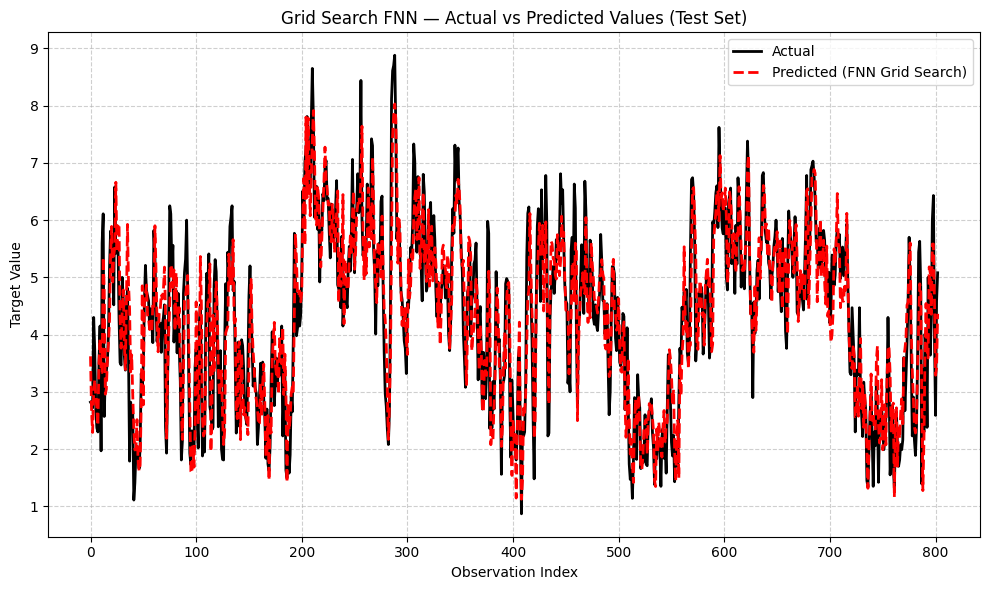

In [11]:
# =============================================================================
# SECTION 2 — GRID SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Grid Search

# Define parameter grid for MLPRegressor
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam'],
    'learning_rate':      ['constant', 'adaptive'],
    'alpha':              [0.0001, 0.001, 0.01],    # L2 penalty (regularization)
    'max_iter':           [500, 1000]
}

# Initialize model (base — parameters will be tuned by grid)
fnn_grid = MLPRegressor(random_state=RANDOM_SEED)

# Time series cross-validation — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# Setup GridSearchCV — fitted on X_train_scaled only (no test set exposure)
grid_search = GridSearchCV(
    estimator=fnn_grid,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',    # Minimize MSE
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    refit=True    # Refit best model on full X_train_scaled automatically
)

# Fit grid search on scaled training data only
grid_search.fit(X_train_scaled, y_train)

# Best model after grid search
best_fnn_grid = grid_search.best_estimator_

print("\nBest Parameters found:")
print(grid_search.best_params_)

# --- Optimal performance: predict on full X_train_scaled and X_test_scaled ---
y_train_pred_fnn_grid = best_fnn_grid.predict(X_train_scaled)
y_test_pred_fnn_grid  = best_fnn_grid.predict(X_test_scaled)

# Evaluation
print("\n--- Grid Search FNN Evaluation ---")
grid_train_mse,  grid_train_rmse,  grid_train_mae,  grid_train_mape,  grid_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_fnn_grid, label="Train (FNN Grid Search)")
grid_test_mse,   grid_test_rmse,   grid_test_mae,   grid_test_mape,   grid_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_fnn_grid,  label="Test (FNN Grid Search)")

# Plot actual vs predicted on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,           label='Actual',                      color='black', linewidth=2)
plt.plot(y_test_pred_fnn_grid,    label='Predicted (FNN Grid Search)',  color='red',   linestyle='--', linewidth=2)
plt.title('Grid Search FNN — Actual vs Predicted Values (Test Set)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Section 3 — Randomized Search CV Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
{'activation': 'relu', 'alpha': np.float64(0.009932308858067881), 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'adam'}

--- Randomized Search FNN Evaluation ---
Train (FNN Randomized Search) MSE:  0.3636
Train (FNN Randomized Search) RMSE: 0.6030
Train (FNN Randomized Search) MAE:  0.4743
Train (FNN Randomized Search) MAPE: 13.26%
Train (FNN Randomized Search) R²:   0.8557
Test (FNN Randomized Search) MSE:  0.5399
Test (FNN Randomized Search) RMSE: 0.7348
Test (FNN Randomized Search) MAE:  0.5698
Test (FNN Randomized Search) MAPE: 15.52%
Test (FNN Randomized Search) R²:   0.7761


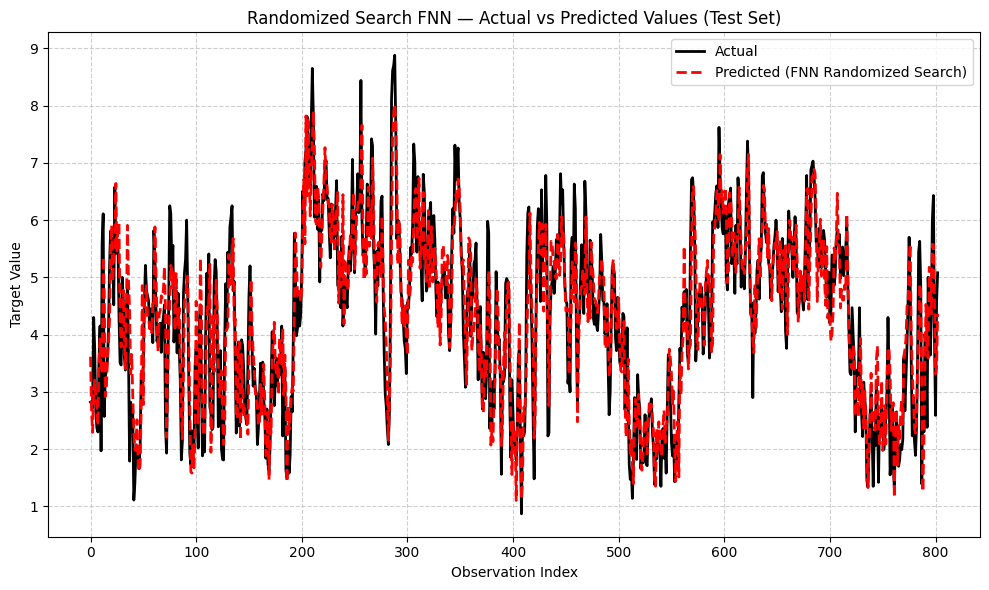

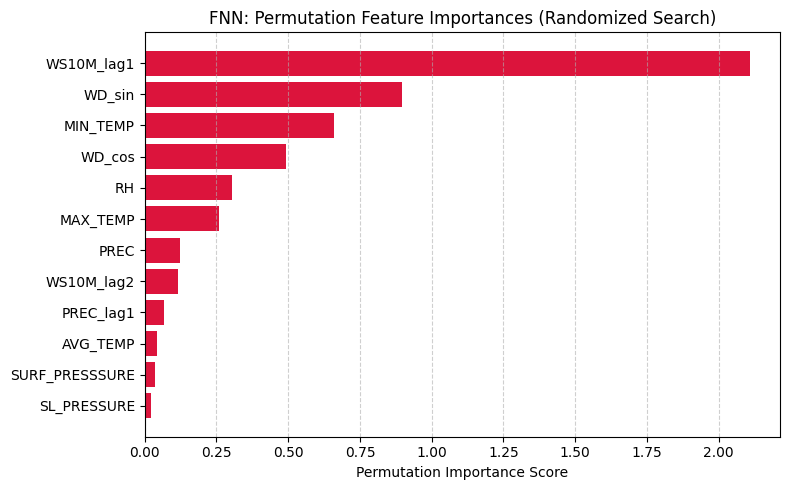

In [12]:
# =============================================================================
# SECTION 3 — RANDOMIZED SEARCH CV  Hyperparameter Tuning
# TimeSeriesSplit cross-validation applied on training data only
# =============================================================================
## Random Search

# Hyperparameter distributions for MLPRegressor
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam'],
    'alpha':              uniform(loc=0.0001, scale=0.01),    # L2 penalty (regularization)
    'learning_rate':      ['constant', 'adaptive'],
    'max_iter':           [500, 1000]
}

# Initialize model
fnn_random = MLPRegressor(random_state=RANDOM_SEED)

# Time Series Cross-Validation — applied on training data only
tscv = TimeSeriesSplit(n_splits=5)

# Randomized Search — fitted on X_train_scaled only (no test set exposure)
random_search = RandomizedSearchCV(
    estimator=fnn_random,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True    # Refit best model on full X_train_scaled automatically
)

# Fit search on scaled training data only
random_search.fit(X_train_scaled, y_train)

# Best model
best_fnn_random = random_search.best_estimator_
print("\nBest Parameters:")
print(random_search.best_params_)

# --- Optimal performance: predict on full X_train_scaled and X_test_scaled ---
y_train_pred_fnn_random = best_fnn_random.predict(X_train_scaled)
y_test_pred_fnn_random  = best_fnn_random.predict(X_test_scaled)

# Evaluation
print("\n--- Randomized Search FNN Evaluation ---")
random_train_mse,  random_train_rmse,  random_train_mae,  random_train_mape,  random_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_fnn_random, label="Train (FNN Randomized Search)")
random_test_mse,   random_test_rmse,   random_test_mae,   random_test_mape,   random_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_fnn_random,  label="Test (FNN Randomized Search)")

# Plot actual vs predicted values on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,              label='Actual',                          color='black', linewidth=2)
plt.plot(y_test_pred_fnn_random,     label='Predicted (FNN Randomized Search)', color='red', linestyle='--', linewidth=2)
plt.title('Randomized Search FNN — Actual vs Predicted Values (Test Set)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Permutation Feature Importance (approximate for FNN)
perm_result = permutation_importance(
    best_fnn_random,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)

# FIX: X_test_scaled is a NumPy array — use X_test.columns for feature names
importance_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot permutation importances
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='crimson')
plt.xlabel('Permutation Importance Score')
plt.title('FNN: Permutation Feature Importances (Randomized Search)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Section 4 — Optuna Hyperparameter Tuning
TimeSeriesSplit cross-validation applied on training data only.  
**Fix**: Original code trained CV folds on unscaled `X_train.iloc[...]` while indices came from scaled `X_train_sub` — corrupting the entire Optuna tuning. Corrected to use `X_train_scaled` consistently throughout.


Best Trial:
FrozenTrial(number=16, state=<TrialState.COMPLETE: 1>, values=[0.5187188669837853], datetime_start=datetime.datetime(2026, 3, 10, 5, 46, 9, 623203), datetime_complete=datetime.datetime(2026, 3, 10, 5, 46, 18, 562452), params={'n_layers': 1, 'n_units_l0': 39, 'activation': 'relu', 'alpha': 0.001767819083219806, 'learning_rate': 'constant'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_l0': IntDistribution(high=150, log=False, low=20, step=1), 'activation': CategoricalDistribution(choices=('relu', 'tanh')), 'alpha': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'learning_rate': CategoricalDistribution(choices=('constant', 'adaptive'))}, trial_id=16, value=None)

Best Parameters:
{'n_layers': 1, 'n_units_l0': 39, 'activation': 'relu', 'alpha': 0.001767819083219806, 'learning_rate': 'constant'}

--- Optimized FNN Evaluation (Optuna) ---
Train (FNN Optuna) MSE:  0.3

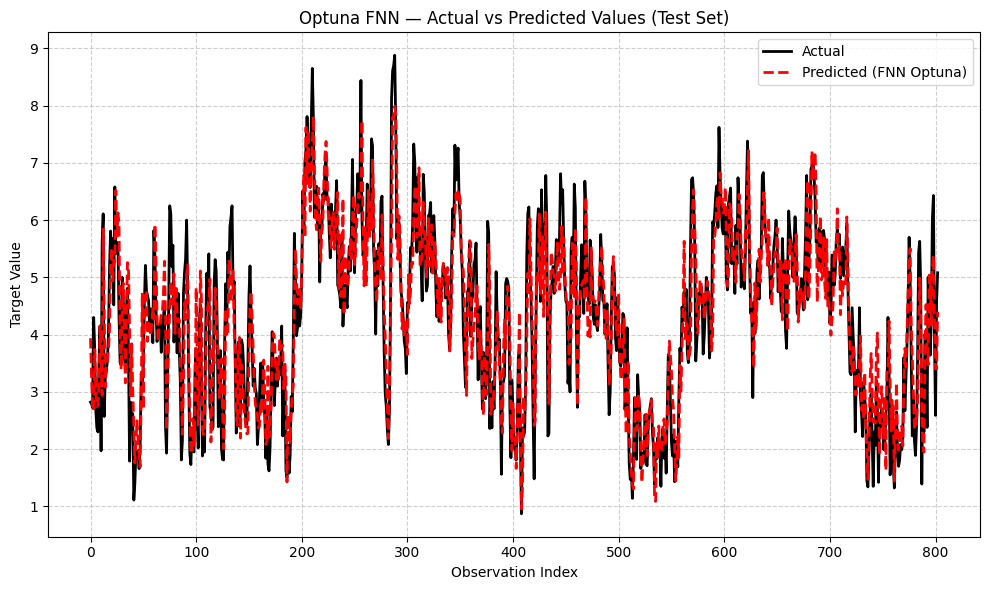

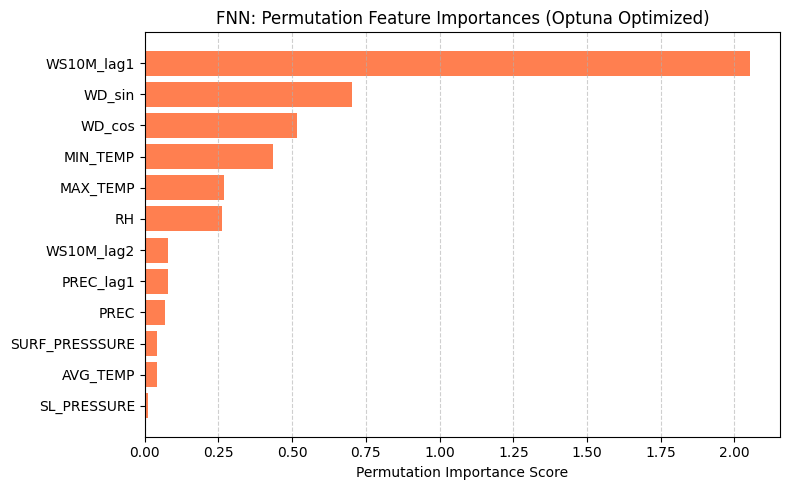

In [13]:
# =============================================================================
# SECTION 4 — OPTUNA  Hyperparameter Tuning
# FIX: Original objective split X_train_sub (scaled NumPy array) for indices but
#      then retrieved X_train.iloc[train_idx] — the raw, unscaled DataFrame.
#      Hyperparameters were therefore optimised on a completely different data
#      distribution than the scaled data the final model ran on.
#      Fixed: CV folds now consistently index and use X_train_scaled.
# =============================================================================
## Optuna

# Optuna objective function for MLPRegressor (FNN)
def fnn_objective(trial):
    # Suggested hyperparameters for MLP
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f'n_units_l{i}', 20, 150) for i in range(n_layers)
    )

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
        'solver':             'adam',    # fixed
        # FIX: suggest_loguniform is deprecated — replaced with suggest_float(..., log=True)
        'alpha':              trial.suggest_float('alpha', 1e-5, 1e-2, log=True),    # L2 regularization
        'learning_rate':      trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'max_iter':           1000,
        'random_state':       RANDOM_SEED
    }

    # Use TimeSeriesSplit CV on X_train_scaled only — avoids any exposure to held-out X_test
    # FIX: previously the fold fit used unscaled X_train.iloc[...] while indices came
    #      from the scaled X_train_scaled array — now both are consistently scaled
    tscv_optuna = TimeSeriesSplit(n_splits=5)
    mse_scores  = []

    for fold_train_idx, fold_val_idx in tscv_optuna.split(X_train_scaled):
        X_fold_tr  = X_train_scaled[fold_train_idx]
        X_fold_val = X_train_scaled[fold_val_idx]
        y_fold_tr  = y_train.iloc[fold_train_idx]
        y_fold_val = y_train.iloc[fold_val_idx]

        model = MLPRegressor(**params)
        model.fit(X_fold_tr, y_fold_tr)
        preds = model.predict(X_fold_val)
        # Return mean CV MSE across all folds — no test set exposure
        mse_scores.append(mean_squared_error(y_fold_val, preds))

    return np.mean(mse_scores)

# Create Optuna study
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study.optimize(fnn_objective, n_trials=30, timeout=600)    # max 10 min or 30 trials

print("\nBest Trial:")
print(study.best_trial)
print("\nBest Parameters:")
print(study.best_params)

# --- Optimal performance: refit final model on full X_train_scaled ---
best_params = study.best_params

# Build hidden_layer_sizes tuple from the per-layer units suggested by Optuna
hidden_layer_sizes = tuple(
    best_params[f'n_units_l{i}'] for i in range(best_params['n_layers'])
)

final_fnn_optuna = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes,
    activation=best_params['activation'],
    solver='adam',
    alpha=best_params['alpha'],
    learning_rate=best_params['learning_rate'],
    max_iter=1000,
    random_state=RANDOM_SEED
)

final_fnn_optuna.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_fnn_optuna = final_fnn_optuna.predict(X_train_scaled)
y_test_pred_fnn_optuna  = final_fnn_optuna.predict(X_test_scaled)

# Evaluate
print("\n--- Optimized FNN Evaluation (Optuna) ---")
optuna_train_mse,  optuna_train_rmse,  optuna_train_mae,  optuna_train_mape,  optuna_train_r2  = \
    evaluate_metrics(y_train, y_train_pred_fnn_optuna, label="Train (FNN Optuna)")
optuna_test_mse,   optuna_test_rmse,   optuna_test_mae,   optuna_test_mape,   optuna_test_r2   = \
    evaluate_metrics(y_test,  y_test_pred_fnn_optuna,  label="Test (FNN Optuna)")

# Plot actual vs predicted values on test set
plt.figure(figsize=(10, 6))
plt.plot(y_test.values,              label='Actual',                        color='black', linewidth=2)
plt.plot(y_test_pred_fnn_optuna,     label='Predicted (FNN Optuna)',         color='red',   linestyle='--', linewidth=2)
plt.title('Optuna FNN — Actual vs Predicted Values (Test Set)')
plt.xlabel('Observation Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Permutation importance for FNN
perm_result = permutation_importance(
    final_fnn_optuna,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error'
)

# FIX: X_test_scaled is a NumPy array — use X_test.columns for feature names
importance_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='coral')
plt.xlabel('Permutation Importance Score')
plt.title('FNN: Permutation Feature Importances (Optuna Optimized)')
plt.gca().invert_yaxis()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Final Comparison Table

In [14]:
# =============================================================================
# FINAL COMPARISON TABLE
# Optimal train/test performance for each method
# (best model refitted on full X_train_scaled, evaluated on held-out X_test_scaled)
# =============================================================================

# Create a DataFrame with the evaluation metrics for each model
data = {
    'Method':         ['Original Model', 'Grid Search', 'Randomized Search', 'Optuna'],

    'Train MSE':      [fnn_train_mse,   grid_train_mse,   random_train_mse,   optuna_train_mse],
    'Test MSE':       [fnn_test_mse,    grid_test_mse,    random_test_mse,    optuna_test_mse],

    'Train MAE':      [fnn_train_mae,   grid_train_mae,   random_train_mae,   optuna_train_mae],
    'Test MAE':       [fnn_test_mae,    grid_test_mae,    random_test_mae,    optuna_test_mae],

    'Train RMSE':     [fnn_train_rmse,  grid_train_rmse,  random_train_rmse,  optuna_train_rmse],
    'Test RMSE':      [fnn_test_rmse,   grid_test_rmse,   random_test_rmse,   optuna_test_rmse],

    'Train MAPE (%)': [fnn_train_mape,  grid_train_mape,  random_train_mape,  optuna_train_mape],
    'Test MAPE (%)':  [fnn_test_mape,   grid_test_mape,   random_test_mape,   optuna_test_mape],

    'Train R²':       [fnn_train_r2,    grid_train_r2,    random_train_r2,    optuna_train_r2],
    'Test R²':        [fnn_test_r2,     grid_test_r2,     random_test_r2,     optuna_test_r2],
}

# Convert the dictionary into a pandas DataFrame
metrics_df = pd.DataFrame(data)

# Print the title
print("\n" + "=" * 60)
print("   Variable Set 1 — FNN Modelling")
print("   (Optimal Train/Test Performance per Method)")
print("=" * 60 + "\n")

# Display the table
print(metrics_df.to_string(index=False))

# Save the DataFrame to an Excel file
metrics_df.to_excel('VariableSet1_FNN.xlsx', index=False)
print("\nResults saved to 'VariableSet1_FNN.xlsx'")


   Variable Set 1 — FNN Modelling
   (Optimal Train/Test Performance per Method)

           Method  Train MSE  Test MSE  Train MAE  Test MAE  Train RMSE  Test RMSE  Train MAPE (%)  Test MAPE (%)  Train R²  Test R²
   Original Model   0.237064  0.634945   0.380449  0.606056    0.486893   0.796834       10.634494      16.372968  0.905901 0.736695
      Grid Search   0.363399  0.539778   0.474518  0.569484    0.602826   0.734696       13.277313      15.498665  0.855754 0.776160
Randomized Search   0.363560  0.539925   0.474261  0.569777    0.602960   0.734796       13.263610      15.516593  0.855690 0.776099
           Optuna   0.388092  0.530804   0.490729  0.566069    0.622970   0.728563       13.670079      15.371047  0.845952 0.779881

Results saved to 'VariableSet1_FNN.xlsx'
